In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

In [6]:
df=pd.read_csv('wind_dataset.csv',parse_dates=['DATE'],index_col='DATE')

In [7]:
df.head()

,WIND,IND,RAIN,IND.1,T.MAX,IND.2,T.MIN,T.MIN.G
DATE,,,,,,,,
1961-01-01,13.67,0,0.2,0.0,9.5,0.0,3.7,-1.0
1961-01-02,11.50,0,5.1,0.0,7.2,0.0,4.2,1.1
1961-01-03,11.25,0,0.4,0.0,5.5,0.0,0.5,-0.5
1961-01-04,8.63,0,0.2,0.0,5.6,0.0,0.4,-3.2
1961-01-05,11.92,0,10.4,0.0,7.2,1.0,-1.5,-7.5


In [8]:
df.shape

(6574, 8)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 6574 entries, 1961-01-01 to 1978-12-31
Data columns (total 8 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   WIND     6574 non-null   float64
 1   IND      6574 non-null   int64  
 2   RAIN     6574 non-null   float64
 3   IND.1    6513 non-null   float64
 4   T.MAX    5953 non-null   float64
 5   IND.2    6513 non-null   float64
 6   T.MIN    5900 non-null   float64
 7   T.MIN.G  6214 non-null   float64
dtypes: float64(7), int64(1)
memory usage: 462.2 KB


In [10]:
df.isnull().sum()

WIND         0
IND          0
RAIN         0
IND.1       61
T.MAX      621
IND.2       61
T.MIN      674
T.MIN.G    360
dtype: int64

In [15]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
import datetime
from sklearn.metrics import mean_absolute_error

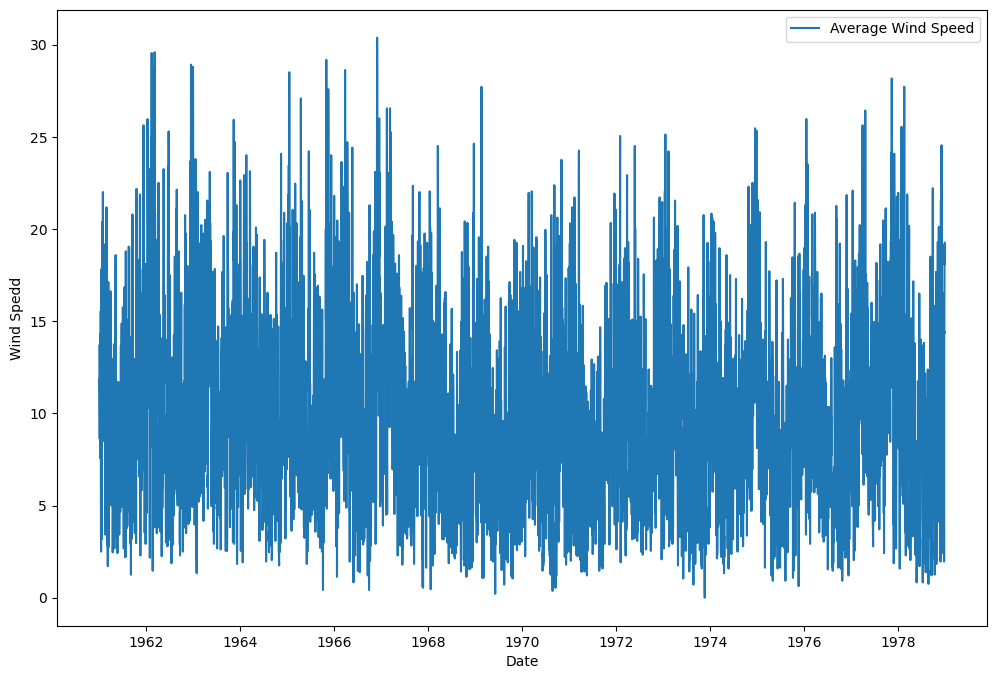

In [17]:
plt.figure(figsize=(12,8))

plt.plot(df.index,df['WIND'],label='Average Wind Speed')

plt.xlabel('Date')
plt.ylabel('Wind Spedd')

plt.legend()
plt.show()

In [25]:
corr_mat=df.corr()
print(corr_mat)

             WIND       IND      RAIN     IND.1     T.MAX     IND.2     T.MIN  \
WIND     1.000000 -0.038578  0.120876  0.070512 -0.242559  0.047860 -0.093014   
IND     -0.038578  1.000000 -0.148535 -0.028176 -0.075365 -0.015173 -0.050447   
RAIN     0.120876 -0.148535  1.000000  0.023944 -0.044248  0.012567  0.011067   
IND.1    0.070512 -0.028176  0.023944  1.000000 -0.036045  0.909739 -0.033344   
T.MAX   -0.242559 -0.075365 -0.044248 -0.036045  1.000000 -0.247060  0.789980   
IND.2    0.047860 -0.015173  0.012567  0.909739 -0.247060  1.000000 -0.535746   
T.MIN   -0.093014 -0.050447  0.011067 -0.033344  0.789980 -0.535746  1.000000   
T.MIN.G  0.012823 -0.064185  0.027365 -0.004040  0.679804 -0.129421  0.906869   

          T.MIN.G  
WIND     0.012823  
IND     -0.064185  
RAIN     0.027365  
IND.1   -0.004040  
T.MAX    0.679804  
IND.2   -0.129421  
T.MIN    0.906869  
T.MIN.G  1.000000  


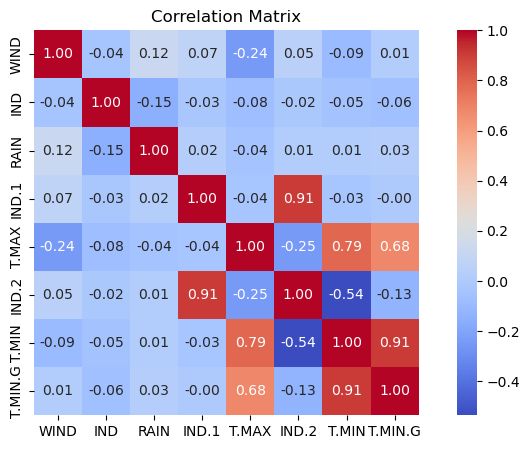

In [26]:
plt.figure(figsize=(10,5))

sns.heatmap(corr_mat,annot=True,cmap='coolwarm',fmt='.2f',square=True)
plt.title('Correlation Matrix')

plt.show()

C:\Users\91637\AppData\Local\Temp\ipykernel_31740\3336334417.py:17: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


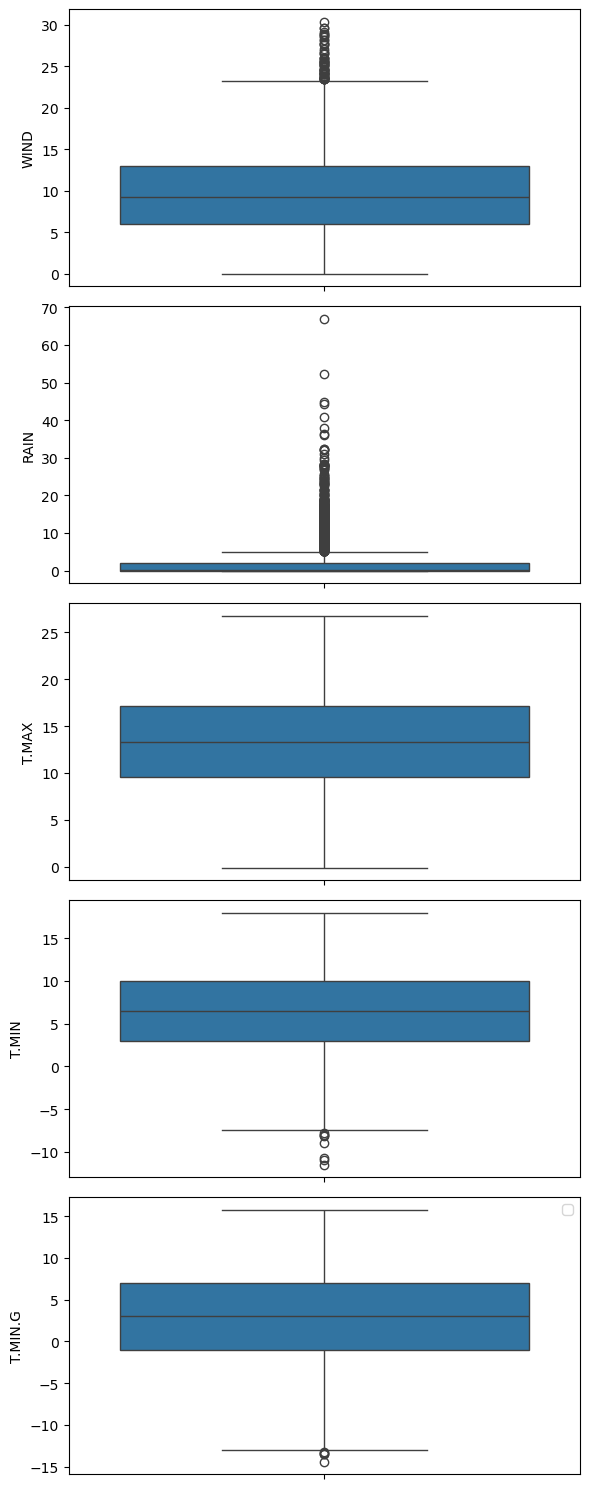

In [39]:
plt.figure(figsize=(6,15))

plt.subplot(511)
sns.boxplot(df['WIND'])

plt.subplot(512)
sns.boxplot(df['RAIN'])

plt.subplot(513)
sns.boxplot(df['T.MAX'])

plt.subplot(514)
sns.boxplot(df['T.MIN'])

plt.subplot(515)
sns.boxplot(df['T.MIN.G'])
plt.legend()
plt.tight_layout()
plt.show()


In [48]:
df.skew().sort_values(ascending=False)


RAIN       4.495113
IND.1      2.903395
IND        2.720655
IND.2      2.532609
WIND       0.645793
T.MIN      0.007427
T.MIN.G   -0.121746
T.MAX     -0.384366
dtype: float64

C:\Users\91637\AppData\Local\Temp\ipykernel_31740\2524704844.py:12: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


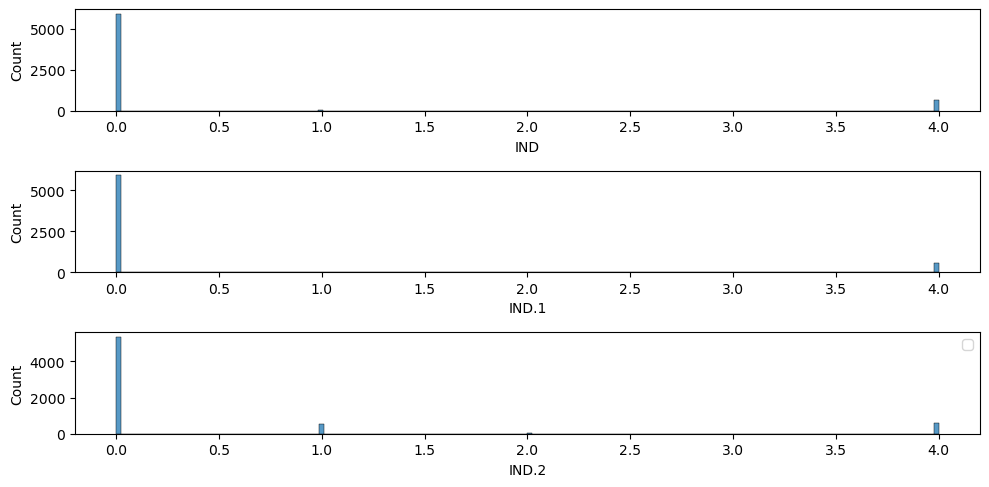

In [40]:
plt.figure(figsize=(10,5))

plt.subplot(311)
sns.histplot(df['IND'])

plt.subplot(312)
sns.histplot(df['IND.1'])

plt.subplot(313)
sns.histplot(df['IND.2'])

plt.legend()
plt.tight_layout()
plt.show()

In [104]:
df.values

array([[13.67      ,  0.        ,  0.18232156, ...,  0.        ,
         0.        ,  0.        ],
       [11.5       ,  0.        ,  1.80828877, ...,  0.        ,
         0.        ,  0.        ],
       [11.25      ,  0.        ,  0.33647224, ...,  0.        ,
         0.        ,  0.        ],
       ...,
       [19.17      ,  0.        ,  2.75366071, ...,  0.        ,
         0.        ,  0.        ],
       [18.08      ,  0.        ,  1.77495235, ...,  0.        ,
         0.        ,  0.        ],
       [19.25      ,  0.        ,  0.40546511, ...,  0.        ,
         0.        ,  0.69314718]], shape=(6574, 12))

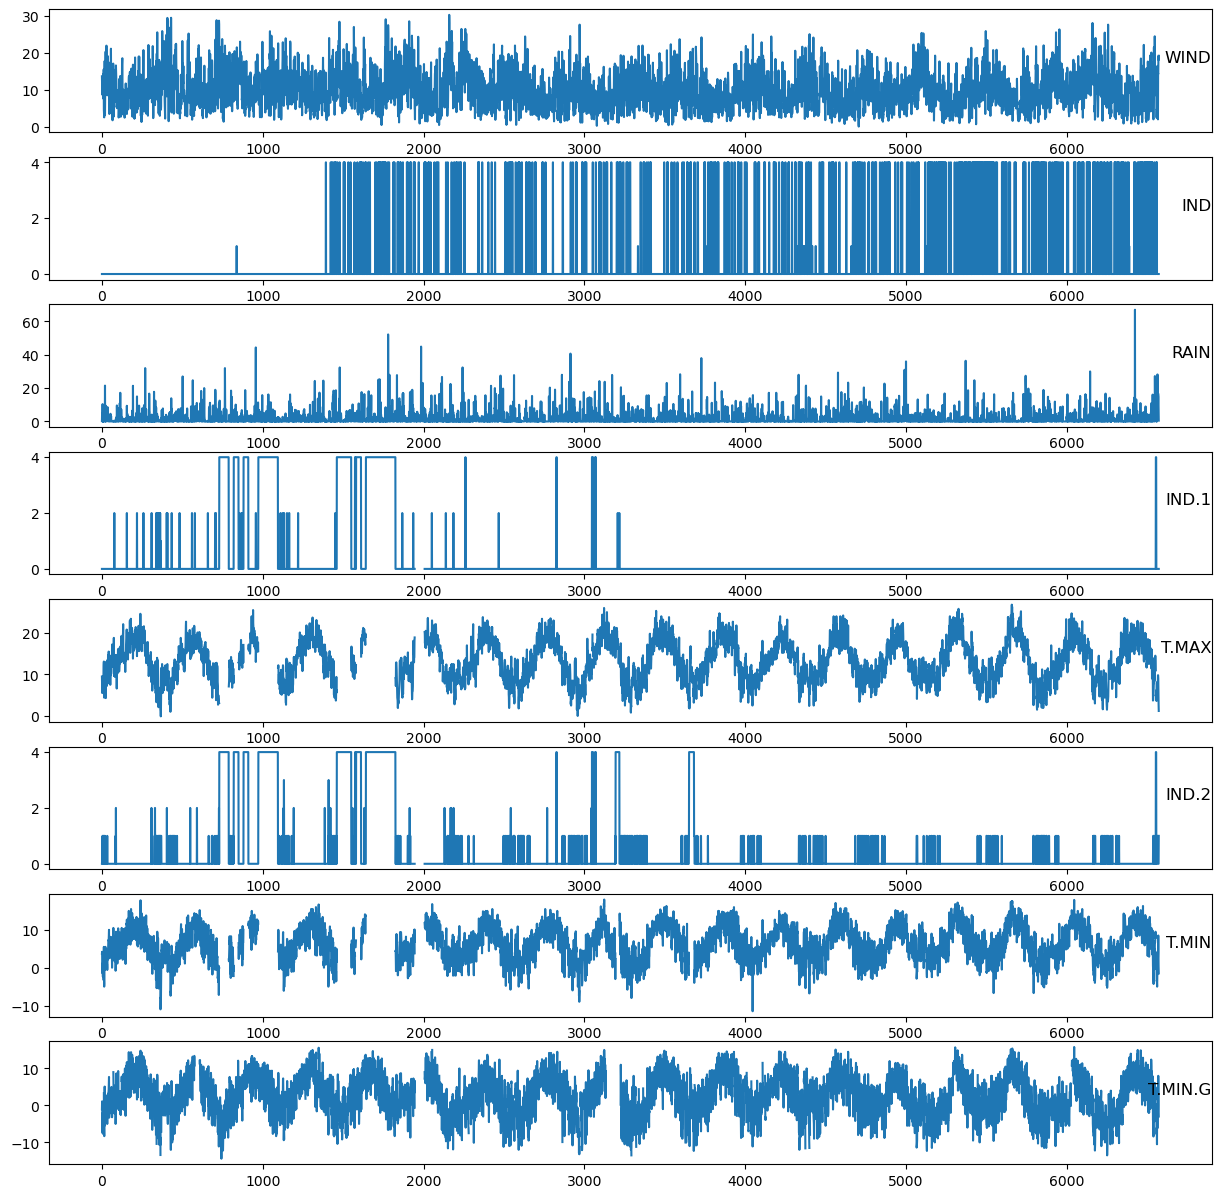

In [41]:
from matplotlib import pyplot
# load dataset
values = df.values
# specify columns to plot
groups = [0, 1, 2, 3,4, 5, 6, 7]
i = 1
# plot each column
pyplot.figure(figsize=(15,15))
for group in groups:
    pyplot.subplot(len(groups), 1, i)
    pyplot.plot(values[:, group])
    pyplot.title(df.columns[group], y=0.5, loc='right')
    i += 1
pyplot.show()

In [44]:
df=df.fillna(0)

In [45]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 6574 entries, 1961-01-01 to 1978-12-31
Data columns (total 8 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   WIND     6574 non-null   float64
 1   IND      6574 non-null   int64  
 2   RAIN     6574 non-null   float64
 3   IND.1    6574 non-null   float64
 4   T.MAX    6574 non-null   float64
 5   IND.2    6574 non-null   float64
 6   T.MIN    6574 non-null   float64
 7   T.MIN.G  6574 non-null   float64
dtypes: float64(7), int64(1)
memory usage: 462.2 KB


In [46]:
6574*0.8

5259.200000000001

In [57]:
import numpy as np

for col in ['RAIN', 'IND', 'IND.1', 'IND.2']:
    df[col] = np.log1p(df[col])  # use in-place or save to new cols


In [58]:
from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()
scaled_data = scaler.fit_transform(df[['RAIN', 'IND', 'IND.1', 'IND.2', 'WIND']])


In [60]:
from sklearn.preprocessing import StandardScaler

std_scaler = StandardScaler()
scaled_sym = std_scaler.fit_transform(df[['T.MIN', 'T.MIN.G', 'T.MAX']])


In [61]:
import numpy as np

X_final = np.concatenate([scaled_data, scaled_sym], axis=1)


In [65]:
X_final.shape

(6574, 8)

In [66]:
train_size = int(len(X_final) * 0.8)

X_train = X_final[:train_size]
X_test  = X_final[train_size:]


In [126]:
n_steps_in = 10    # e.g., use past 30 days
n_steps_out = 5   # predict 1 day ahead


In [127]:
def create_sequences(data, n_in, n_out):
    X, y = [], []
    for i in range(len(data) - n_in - n_out + 1):
        X.append(data[i : i + n_in])
        y.append(data[i + n_in : i + n_in + n_out])
    return np.array(X), np.array(y)

X, y = create_sequences(X_final, n_steps_in, n_steps_out)


In [128]:
train_size = int(len(X) * 0.8)

X_train = X[:train_size]
X_test  = X[train_size:]

y_train = y[:train_size]
y_test  = y[train_size:]


In [129]:
n_timesteps = X_train.shape[1]   # e.g., 30
n_features = X_train.shape[2]    # e.g., 8
n_outputs = 5    

In [131]:
encoder_inputs=tf.keras.layers.Input(shape=(n_steps_in,n_features))
encoder_l1=tf.keras.layers.LSTM(100,return_state=True)
encoder_outputs1=encoder_l1(encoder_inputs)
encoder_state1=encoder_outputs1[1:]

decoder_inputs=tf.keras.layers.RepeatVector(n_steps_out)(encoder_outputs1[0])

decoder_l1=tf.keras.layers.LSTM(100,return_sequences=True)(decoder_inputs,initial_state=encoder_state1)
decoder_output1=tf.keras.layers.TimeDistributed(tf.keras.layers.Dense(n_features))(decoder_l1)

model_e1d1=tf.keras.models.Model(encoder_inputs,decoder_output1)

In [132]:
model_e1d1.summary()

Model: "functional_27"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_12 (InputLayer)   │ (None, 10, 8)             │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ lstm_12 (LSTM)                │ [(None, 100), (None,      │          43,600 │ input_layer_12[0][0]       │
│                               │ 100), (None, 100)]        │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ repeat_vector (RepeatVector)  │ (None, 5, 100)            │               0 │ lstm_12[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ lstm_13 (LSTM)                │ (None, 5, 100)            │          80,400 │ repeat_vector[0][0],       │
│                               │                           │                 │ lstm_12[0][1],             │
│                               │                           │                 │ lstm_12[0][2]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ time_distributed              │ (None, 5, 8)              │             808 │ lstm_13[0][0]              │
│ (TimeDistributed)             │                           │                 │                            │
└───────────────────────────────┴───────────────────────────┴─────────────────┴────────────────────────────┘

 Total params: 124,808 (487.53 KB)

 Trainable params: 124,808 (487.53 KB)

 Non-trainable params: 0 (0.00 B)

In [155]:
# Input
encoder_input1 = tf.keras.layers.Input(shape=(n_steps_in, n_features))

# Encoder Layer 1 — with states
encoder_l1_1 = tf.keras.layers.LSTM(100, return_sequences=True, return_state=True)
encoder_seq1, h1, c1 = encoder_l1_1(encoder_input1)
encoder_state1_1 = [h1, c1]

# Encoder Layer 2 — with states
encoder_l1_2 = tf.keras.layers.LSTM(100, return_state=True)
encoder_output, h2, c2 = encoder_l1_2(encoder_seq1)
encoder_state1_2 = [h2, c2]

# Decoder
decoder_inputs1 = tf.keras.layers.RepeatVector(n_steps_out)(encoder_output)

decoder_l1_1 = tf.keras.layers.LSTM(100, return_sequences=True)
decoder_seq1 = decoder_l1_1(decoder_inputs1, initial_state=encoder_state1_1)

decoder_l1_2 = tf.keras.layers.LSTM(100, return_sequences=True)
decoder_seq2 = decoder_l1_2(decoder_seq1, initial_state=encoder_state1_2)

decoder_output2 = tf.keras.layers.TimeDistributed(
    tf.keras.layers.Dense(n_features)
)(decoder_seq2)

# Final model
modele2d2 = tf.keras.models.Model(encoder_input1, decoder_output2)


In [156]:
modele2d2.summary()

Model: "functional_30"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_21 (InputLayer)   │ (None, 10, 8)             │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ lstm_32 (LSTM)                │ [(None, 10, 100), (None,  │          43,600 │ input_layer_21[0][0]       │
│                               │ 100), (None, 100)]        │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ lstm_33 (LSTM)                │ [(None, 100), (None,      │          80,400 │ lstm_32[0][0]              │
│                               │ 100), (None, 100)]        │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ repeat_vector_4               │ (None, 5, 100)            │               0 │ lstm_33[0][0]              │
│ (RepeatVector)                │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ lstm_34 (LSTM)                │ (None, 5, 100)            │          80,400 │ repeat_vector_4[0][0],     │
│                               │                           │                 │ lstm_32[0][1],             │
│                               │                           │                 │ lstm_32[0][2]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ lstm_35 (LSTM)                │ (None, 5, 100)            │          80,400 │ lstm_34[0][0],             │
│                               │                           │                 │ lstm_33[0][1],             │
│                               │                           │                 │ lstm_33[0][2]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ time_distributed_3            │ (None, 5, 8)              │             808 │ lstm_35[0][0]              │
│ (TimeDistributed)             │                           │                 │                            │
└───────────────────────────────┴───────────────────────────┴─────────────────┴────────────────────────────┘

 Total params: 285,608 (1.09 MB)

 Trainable params: 285,608 (1.09 MB)

 Non-trainable params: 0 (0.00 B)

In [157]:
reduce_lr=tf.keras.callbacks.LearningRateScheduler(lambda x: 1e-3 * 0.9**x)
model_e1d1.compile(optimizer=tf.keras.optimizers.Adam(),loss=tf.keras.losses.Huber())
history_e1d1=model_e1d1.fit(X_train,y_train,epochs=25,validation_data=(X_test,y_test),batch_size=32,verbose=0,callbacks=[reduce_lr])


In [158]:

modele2d2.compile(optimizer=tf.keras.optimizers.Adam(),loss=tf.keras.losses.Huber())
history_e2d2=modele2d2.fit(X_train,y_train,epochs=25,validation_data=(X_test,y_test),batch_size=32,verbose=0,callbacks=[reduce_lr])

In [161]:
pred_e1d1=model_e1d1.predict(X_test)
pred_e2d2=modele2d2.predict(X_test)

41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step   


In [162]:
from sklearn.metrics import mean_absolute_error
for index,i in enumerate(train_df.columns):
  print(i)
  for j in range(1,6):
    print("Day ",j,":")
    print("MAE-E1D1 : ",mean_absolute_error(y_test[:,j-1,index],pred_e1d1[:,j-1,index]),end=", ")
    print("MAE-E2D2 : ",mean_absolute_error(y_test[:,j-1,index],pred_e2d2[:,j-1,index]))
  print()
  # print()

WIND
Day  1 :
MAE-E1D1 :  0.5689828875794789, MAE-E2D2 :  0.5549256119654775
Day  2 :
MAE-E1D1 :  0.6141392533386058, MAE-E2D2 :  0.5757322759342525
Day  3 :
MAE-E1D1 :  0.6245605551399946, MAE-E2D2 :  0.5826260369538266
Day  4 :
MAE-E1D1 :  0.632232703373075, MAE-E2D2 :  0.5883157716468753
Day  5 :
MAE-E1D1 :  0.62844532563994, MAE-E2D2 :  0.5896911981479356

IND
Day  1 :
MAE-E1D1 :  0.4030905602921344, MAE-E2D2 :  0.38348189932477256
Day  2 :
MAE-E1D1 :  0.4038677304251845, MAE-E2D2 :  0.38447113588135673
Day  3 :
MAE-E1D1 :  0.40074069059194023, MAE-E2D2 :  0.38224259790233206
Day  4 :
MAE-E1D1 :  0.4005390899058384, MAE-E2D2 :  0.3776517757641786
Day  5 :
MAE-E1D1 :  0.4019336196149425, MAE-E2D2 :  0.376549345137474

RAIN
Day  1 :
MAE-E1D1 :  0.054613561078536384, MAE-E2D2 :  0.044438214815834494
Day  2 :
MAE-E1D1 :  0.05629981656159537, MAE-E2D2 :  0.039126401143272926
Day  3 :
MAE-E1D1 :  0.06464792127523335, MAE-E2D2 :  0.041056866637703124
Day  4 :
MAE-E1D1 :  0.070008004275274